# Supervised CNN for wafer map defect classification

Trains a CNN that reads a wafer map and names the failure signature on it (edge ring,
scratch, center cluster, and so on), so failing wafers can be sorted by probable cause
instead of eyeballed one at a time. This is the exact model behind the live tool at
https://wafer.baselinetech.ie. The notebook covers the data, the training run, and the
test results; all outputs are saved from the run, so nothing needs re-executing to read it.

Dataset is the public WM-811K set: 811,457 wafer maps from 46,293 production lots of a real fab (Wu, Jang & Chen, IEEE TSM 2015). 172,950 maps carry an engineer-assigned failure signature label across 9 classes. Each map is a die grid where 0 = outside the wafer, 1 = passing die, 2 = failing die. Maps come in many die-grid sizes, so they are resampled to 64x64 first (`src/data.py`).

In [1]:
import sys
sys.path.append("..")

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from src import data
from src.models import WaferCNN, WaferDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
X, y = data.load_labeled()
print(f"{len(y):,} labeled maps of {X.shape[1]}x{X.shape[2]}  |  device: {device}")

172,950 labeled maps of 64x64  |  device: cuda


## The data

One example of each signature class, and how often each one occurs.

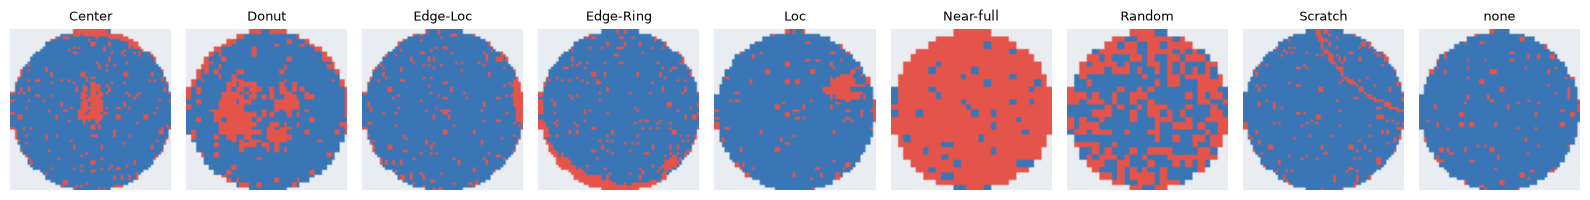

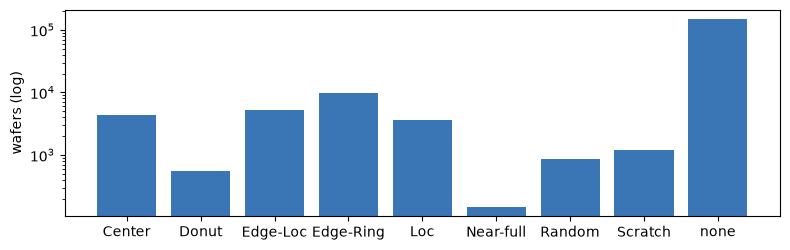

Center       4,294  ( 2.5%)
Donut          555  ( 0.3%)
Edge-Loc     5,189  ( 3.0%)
Edge-Ring    9,680  ( 5.6%)
Loc          3,593  ( 2.1%)
Near-full      149  ( 0.1%)
Random         866  ( 0.5%)
Scratch      1,193  ( 0.7%)
none       147,431  (85.2%)


In [2]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#e9edf1", "#3a76b5", "#e5544b"])  # outside / pass / fail

fig, axes = plt.subplots(1, 9, figsize=(16, 2.1))
for ax, cls in zip(axes, data.CLASSES):
    ax.imshow(X[np.flatnonzero(y == data.CLASSES.index(cls))[0]], cmap=cmap, vmin=0, vmax=2)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

counts = np.bincount(y, minlength=len(data.CLASSES))
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.bar(data.CLASSES, counts, color="#3a76b5")
ax.set_yscale("log")
ax.set_ylabel("wafers (log)")
plt.tight_layout()
plt.show()
for c, n in zip(data.CLASSES, counts):
    print(f"{c:10s} {n:7,}  ({n/len(y):5.1%})")

85% of labeled wafers are clean and the rarest class has 149 wafers, so raw accuracy is meaningless here and training has to compensate for the imbalance. Both handled below.

## Encoding and split

Each map is one-hot encoded into 3 channels (outside / pass / fail) so the network sees wafer geometry and failing die separately rather than as the ordinal values 0-1-2. Split is 80/20 stratified by class, with 10% of train held back for validation. Same seed everywhere so the test set is reproducible.

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.1, stratify=y_tr, random_state=42)
print(f"train {len(y_tr):,} / val {len(y_val):,} / test {len(y_te):,}")


def make_loader(Xs, ys, train=False, batch_size=256):
    ds = WaferDataset(Xs, ys)  # stores uint8, one-hot encodes per item
    if not train:
        return DataLoader(ds, batch_size=batch_size, num_workers=2)
    # sample each wafer inversely to its class frequency -> class-balanced batches
    weights = (1.0 / np.maximum(np.bincount(ys, minlength=len(data.CLASSES)), 1))[ys]
    sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double),
                                    num_samples=len(ys), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=2)


train_loader = make_loader(X_tr, y_tr, train=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_te, y_te)

train 124,524 / val 13,836 / test 34,590


## Model

Three conv blocks (32, 64, 128 filters), each two 3x3 convs with batch norm, then global average pooling into a single linear layer. Small on purpose: 289k parameters trains in minutes and is enough for 64x64 maps. Defined in `src/models.py` (the app loads the same class).

![Pipeline: wafer map through the CNN to threshold routing](https://raw.githubusercontent.com/Jcona2025/wafer-defect-ml/main/reports/figures/cnn_pipeline.png)

End to end: the map is resized and one-hot encoded, three conv blocks halve the spatial size while doubling the filters, and global average pooling collapses to a 128-d embedding. That embedding does double duty — the linear head turns it into class probabilities, and the app's cluster view is the same embedding projected to 2-D with PCA. Downstream, the triage tool routes on max softmax confidence: at or above 0.90 the wafer is auto-binned by signature, below it goes to the human review queue.

In [4]:
model = WaferCNN(n_classes=len(data.CLASSES)).to(device)
print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

WaferCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

## Training

15 epochs, AdamW with a cosine learning-rate schedule, plain cross-entropy (the sampler already balances the batches). Validation tracks balanced accuracy, i.e. mean per-class recall, because that is the metric the rare classes actually move.

In [5]:
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).argmax(1).cpu())
            targets.append(yb)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


torch.manual_seed(42)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)
loss_fn = nn.CrossEntropyLoss()

history = []
for epoch in range(15):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
        running += loss.item() * len(yb)
    sched.step()
    val_pred, val_true = evaluate(model, val_loader)
    bal_acc = float(np.mean([(val_pred[val_true == c] == c).mean()
                             for c in range(len(data.CLASSES))]))
    history.append({"loss": running / len(y_tr), "bal_acc": bal_acc})
    print(f"epoch {epoch:2d}  train loss {running/len(y_tr):.4f}  val balanced acc {bal_acc:.3f}")

torch.save(model.state_dict(), "../models/wafer_cnn.pt")

epoch  0  train loss 0.5839  val balanced acc 0.803


epoch  1  train loss 0.2641  val balanced acc 0.747


epoch  2  train loss 0.1811  val balanced acc 0.819


epoch  3  train loss 0.1348  val balanced acc 0.839


epoch  4  train loss 0.0962  val balanced acc 0.814


...

epoch 10  train loss 0.0186  val balanced acc 0.808


epoch 11  train loss 0.0140  val balanced acc 0.866


epoch 12  train loss 0.0113  val balanced acc 0.865


epoch 13  train loss 0.0106  val balanced acc 0.872


epoch 14  train loss 0.0094  val balanced acc 0.858


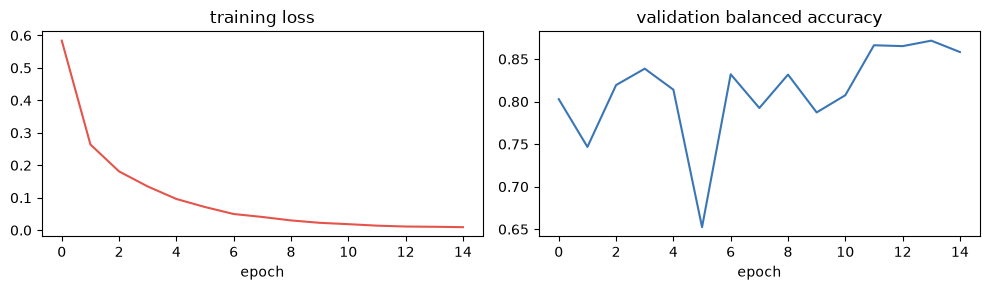

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot([h["loss"] for h in history], color="#e5544b")
axes[0].set_xlabel("epoch"); axes[0].set_title("training loss")
axes[1].plot([h["bal_acc"] for h in history], color="#3a76b5")
axes[1].set_xlabel("epoch"); axes[1].set_title("validation balanced accuracy")
plt.tight_layout()
plt.show()

## Test results

Scored once, on 34,590 held-out wafers at the true production mix (nothing rebalanced or filtered).

In [7]:
pred, true = evaluate(model, test_loader)
print(classification_report(true, pred, target_names=data.CLASSES, digits=3))

              precision    recall  f1-score   support

      Center      0.897     0.866     0.882       859
       Donut      0.822     0.793     0.807       111
    Edge-Loc      0.783     0.832     0.807      1038
   Edge-Ring      0.968     0.976     0.972      1936
         Loc      0.731     0.685     0.707       718
   Near-full      0.906     0.967     0.935        30
      Random      0.869     0.884     0.877       173
     Scratch      0.799     0.665     0.726       239
        none      0.988     0.989     0.989     29486

    accuracy                          0.971     34590
   macro avg      0.863     0.851     0.856     34590
weighted avg      0.971     0.971     0.971     34590



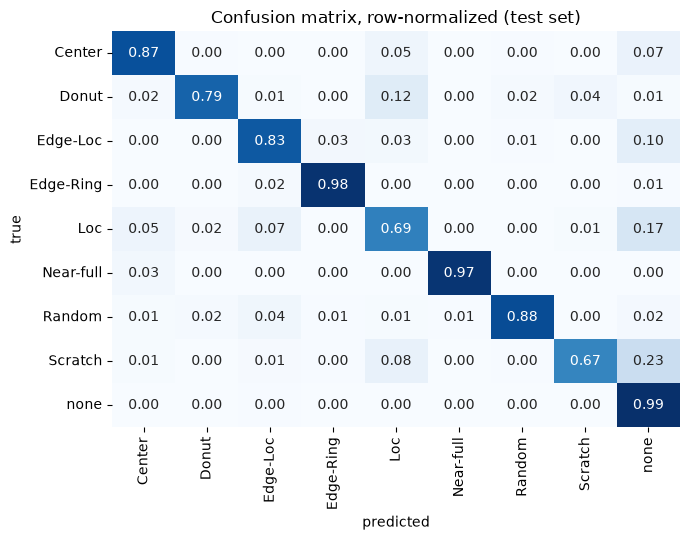

In [8]:
import seaborn as sns
cm = confusion_matrix(true, pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=data.CLASSES, yticklabels=data.CLASSES, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix, row-normalized (test set)")
plt.tight_layout(); plt.show()

## Takeaways

- Quote macro-F1, not accuracy: 85% clean wafers means accuracy is inflated for free.
- Strongest where it matters operationally: "none" precision ~0.99 (a "clean" call is rarely wrong) and Edge-Ring ~0.97.
- Weakest: Loc and Scratch. Loc genuinely overlaps Edge-Loc and Scratch; thin scratches lose die to the 64x64 resize. Rotation/flip augmentation is the first fix to try.
- Known limitation: the split is random by wafer, not grouped by lot, so wafers from the same excursion can sit on both sides of the split. Lot-grouped evaluation is the first thing to rerun before trusting these numbers for a deployment decision.